In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.walk_forward import WalkForwardOptimizer

optimizer = WalkForwardOptimizer(
    lookbacks=[1, 2, 4, 8, 13, 26],
    top_n=3,
    bottom_n=3,
    train_years=5,
    test_years=1
)

print("WalkForwardOptimizer loaded successfully.")

WalkForwardOptimizer loaded successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/raw/daily_prices.csv",
    index_col=0,
    parse_dates=True
)

print("Shape:", prices.shape)
print("Start:", prices.index.min())
print("End:", prices.index.max())

prices.head()

Shape: (6573, 10)
Start: 2000-01-03 00:00:00
End: 2026-02-20 00:00:00


,AAPL,AMZN,GOOGL,JNJ,JPM,KO,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2000-01-03,0.84,4.47,NaN,23.41,22.91,13.61,35.60,0.09,NaN,17.14
2000-01-04,0.77,4.10,NaN,22.55,22.41,13.63,34.40,0.09,NaN,16.81
2000-01-05,0.78,3.49,NaN,22.79,22.27,13.75,34.76,0.08,NaN,17.73
2000-01-06,0.71,3.28,NaN,23.50,22.59,13.77,33.60,0.08,NaN,18.65
2000-01-07,0.75,3.48,NaN,24.50,23.00,14.67,34.04,0.08,NaN,18.59


In [4]:
wf_results = optimizer.run(prices)

print("Walk-forward optimization completed.")

Walk-forward optimization completed.


In [5]:
oos_returns = wf_results["out_of_sample_returns"]
parameter_history = wf_results["parameter_history"]
optimization_history = wf_results["optimization_history"]

print("OOS observations:", len(oos_returns))
print("Walk-forward periods:", len(parameter_history))
print("Optimization runs:", len(optimization_history))

OOS observations: 1102
Walk-forward periods: 22
Optimization runs: 132


In [6]:
parameter_history

,Train Start,Train End,Test Start,Test End,Selected Lookback
0,2000-01-03,2005-01-03,2005-01-03,2006-01-03,8
1,2001-01-03,2006-01-03,2006-01-03,2007-01-03,26
2,2002-01-03,2007-01-03,2007-01-03,2008-01-03,26
3,2003-01-03,2008-01-03,2008-01-03,2009-01-03,8
4,2004-01-03,2009-01-03,2009-01-03,2010-01-03,4
5,2005-01-03,2010-01-03,2010-01-03,2011-01-03,8
6,2006-01-03,2011-01-03,2011-01-03,2012-01-03,8
7,2007-01-03,2012-01-03,2012-01-03,2013-01-03,8
8,2008-01-03,2013-01-03,2013-01-03,2014-01-03,8
9,2009-01-03,2014-01-03,2014-01-03,2015-01-03,4


In [7]:
lookback_frequency = (
    parameter_history["Selected Lookback"]
    .value_counts()
    .sort_index()
)

lookback_frequency

1     1
4     6
8     7
13    4
26    4
Name: Selected Lookback, dtype: int64

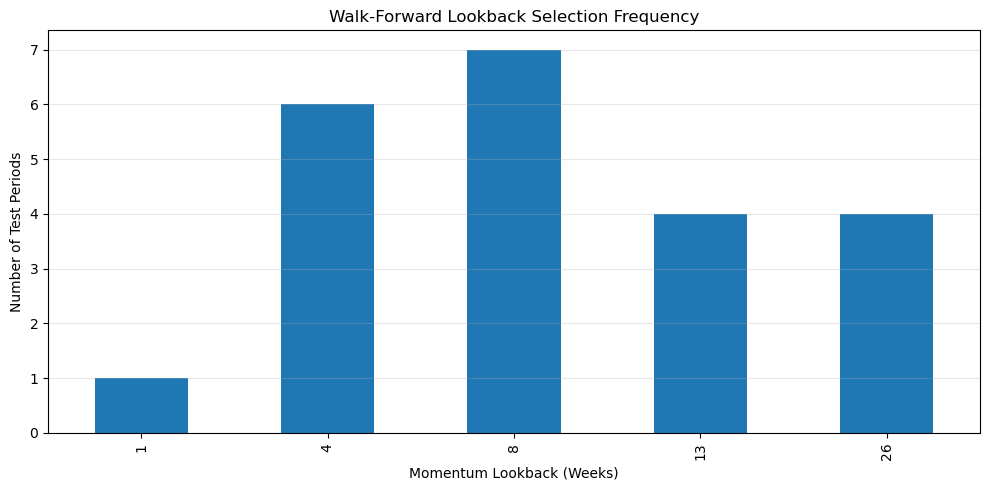

In [8]:
plt.figure(figsize=(10, 5))

lookback_frequency.plot(
    kind="bar"
)

plt.title("Walk-Forward Lookback Selection Frequency")
plt.xlabel("Momentum Lookback (Weeks)")
plt.ylabel("Number of Test Periods")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

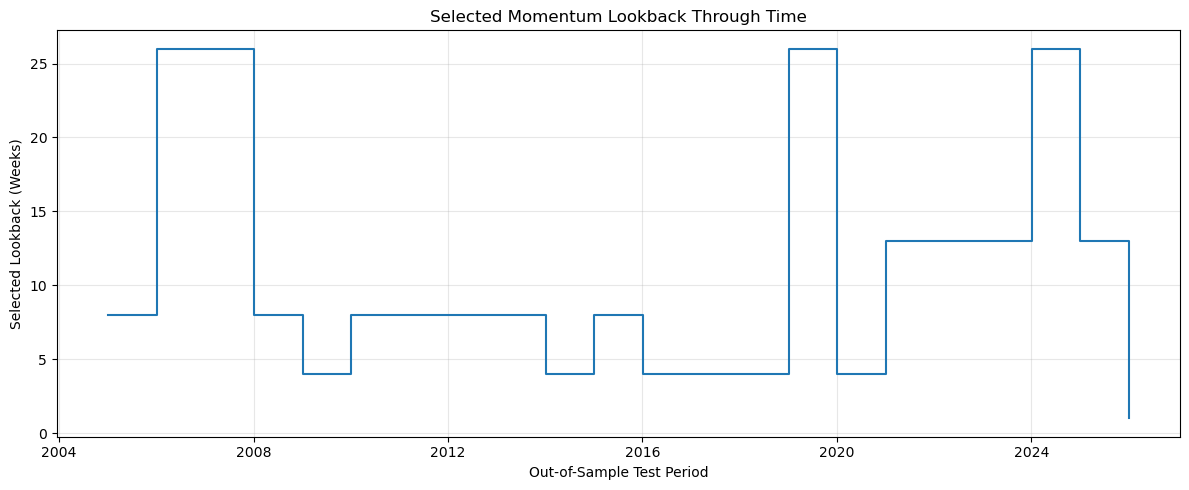

In [9]:
plt.figure(figsize=(12, 5))

plt.step(
    parameter_history["Test Start"],
    parameter_history["Selected Lookback"],
    where="post"
)

plt.title("Selected Momentum Lookback Through Time")
plt.xlabel("Out-of-Sample Test Period")
plt.ylabel("Selected Lookback (Weeks)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
print(oos_returns.head())
print()
print(oos_returns.tail())
print()
print(oos_returns.describe())

Date
2005-01-07    0.002436
2005-01-14   -0.001825
2005-01-21   -0.023203
2005-01-28    0.030944
2005-02-04    0.088502
Freq: W-FRI, dtype: float64

Date
2026-01-16   -0.030813
2026-01-23    0.029144
2026-01-30   -0.023913
2026-02-06    0.138561
2026-02-13   -0.010167
Freq: W-FRI, dtype: float64

count    1102.000000
mean        0.000513
std         0.037708
min        -0.172778
25%        -0.020650
50%         0.001041
75%         0.022089
max         0.148848
dtype: float64


In [11]:
print("Missing values:", oos_returns.isna().sum())
print("Duplicate dates:", oos_returns.index.duplicated().sum())

Missing values: 0
Duplicate dates: 0


In [12]:
from src.performance import PerformanceAnalytics

performance = PerformanceAnalytics()

print("=" * 60)
print("WALK-FORWARD OUT-OF-SAMPLE PERFORMANCE")
print("=" * 60)

print(
    f"Annual Return     : "
    f"{performance.annual_return(oos_returns):.2%}"
)

print(
    f"Annual Volatility : "
    f"{performance.annual_volatility(oos_returns):.2%}"
)

print(
    f"Sharpe Ratio      : "
    f"{performance.sharpe_ratio(oos_returns):.3f}"
)

print(
    f"Maximum Drawdown  : "
    f"{performance.max_drawdown(oos_returns):.2%}"
)

print(
    f"Win Rate          : "
    f"{performance.win_rate(oos_returns):.2%}"
)

WALK-FORWARD OUT-OF-SAMPLE PERFORMANCE
Annual Return     : -1.04%
Annual Volatility : 27.19%
Sharpe Ratio      : -0.038
Maximum Drawdown  : -64.48%
Win Rate          : 50.73%


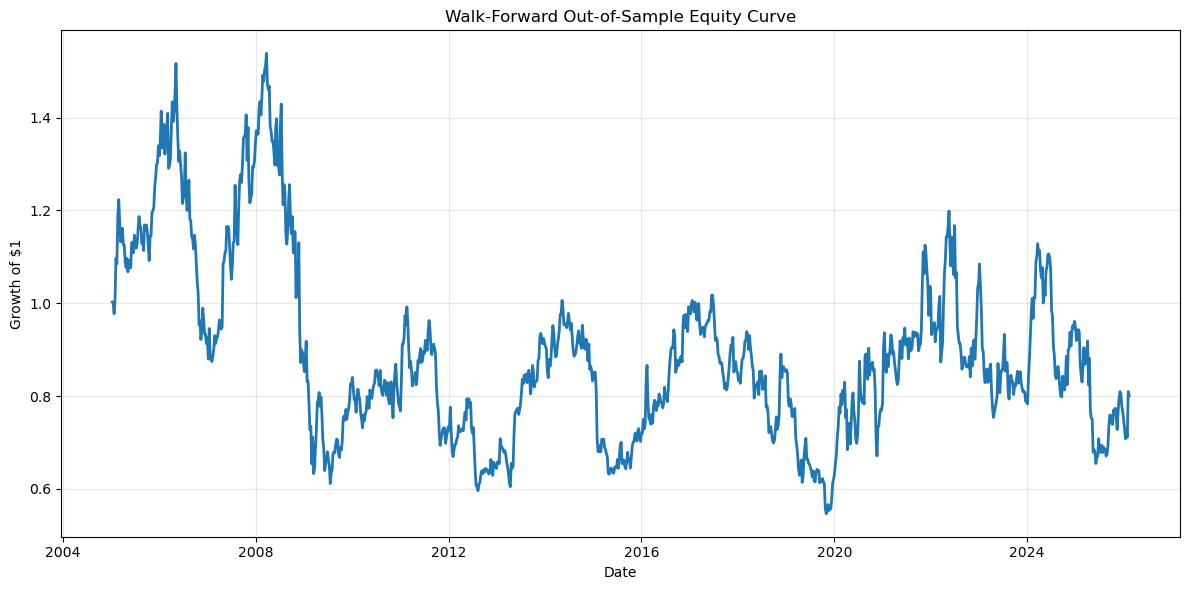

In [13]:
oos_cumulative = (
    1 + oos_returns.fillna(0)
).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    oos_cumulative,
    linewidth=2
)

plt.title("Walk-Forward Out-of-Sample Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
optimization_history.head(12)

,Lookback,Sharpe,Train Start,Train End
0,1,-0.406666,2000-01-03,2005-01-03
1,2,-0.887224,2000-01-03,2005-01-03
2,4,-0.268881,2000-01-03,2005-01-03
3,8,0.017646,2000-01-03,2005-01-03
4,13,-0.050887,2000-01-03,2005-01-03
5,26,-0.218675,2000-01-03,2005-01-03
6,1,-0.090139,2001-01-03,2006-01-03
7,2,-0.701614,2001-01-03,2006-01-03
8,4,-0.166766,2001-01-03,2006-01-03
9,8,0.228130,2001-01-03,2006-01-03


In [15]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

oos_returns.to_csv(
    results_dir / "walk_forward_oos_returns.csv",
    header=["Strategy Return"]
)

parameter_history.to_csv(
    results_dir / "walk_forward_parameters.csv",
    index=False
)

optimization_history.to_csv(
    results_dir / "walk_forward_optimization_history.csv",
    index=False
)

print("Walk-forward results saved successfully.")

Walk-forward results saved successfully.


In [16]:
wf_results = optimizer.run(prices)

oos_returns = wf_results["out_of_sample_returns"]
parameter_history = wf_results["parameter_history"]
optimization_history = wf_results["optimization_history"]

In [17]:
from src.performance import PerformanceAnalytics

performance = PerformanceAnalytics()

print("=" * 60)
print("WALK-FORWARD OUT-OF-SAMPLE PERFORMANCE")
print("=" * 60)

print(
    f"Annual Return     : "
    f"{performance.annual_return(oos_returns):.2%}"
)

print(
    f"Annual Volatility : "
    f"{performance.annual_volatility(oos_returns):.2%}"
)

print(
    f"Sharpe Ratio      : "
    f"{performance.sharpe_ratio(oos_returns):.3f}"
)

print(
    f"Maximum Drawdown  : "
    f"{performance.max_drawdown(oos_returns):.2%}"
)

print(
    f"Win Rate          : "
    f"{performance.win_rate(oos_returns):.2%}"
)

WALK-FORWARD OUT-OF-SAMPLE PERFORMANCE
Annual Return     : -1.04%
Annual Volatility : 27.19%
Sharpe Ratio      : -0.038
Maximum Drawdown  : -64.48%
Win Rate          : 50.73%


In [18]:
print("=" * 70)
print("WALK-FORWARD PARAMETER HISTORY")
print("=" * 70)

parameter_history

WALK-FORWARD PARAMETER HISTORY


,Train Start,Train End,Test Start,Test End,Selected Lookback
0,2000-01-03,2005-01-03,2005-01-03,2006-01-03,8
1,2001-01-03,2006-01-03,2006-01-03,2007-01-03,26
2,2002-01-03,2007-01-03,2007-01-03,2008-01-03,26
3,2003-01-03,2008-01-03,2008-01-03,2009-01-03,8
4,2004-01-03,2009-01-03,2009-01-03,2010-01-03,4
5,2005-01-03,2010-01-03,2010-01-03,2011-01-03,8
6,2006-01-03,2011-01-03,2011-01-03,2012-01-03,8
7,2007-01-03,2012-01-03,2012-01-03,2013-01-03,8
8,2008-01-03,2013-01-03,2013-01-03,2014-01-03,8
9,2009-01-03,2014-01-03,2014-01-03,2015-01-03,4
